<table style="width: 100%; border: none; background: linear-gradient(to bottom, #f8f9fa, #e9ecef); padding: 20px; border-radius: 10px; box-shadow: 0 2px 5px rgba(0,0,0,0.1);">
    <tr>
        <td style="width: 22%; border: none; vertical-align: middle; text-align: center;">
            <img src="https://www.inf.ucv.cl/wp-content/uploads/2020/05/logo_escuela.jpg" width="170" style="max-width: 100%;">
        </td>
        <td style="width: 56%; border: none; vertical-align: middle; text-align: center; padding: 0 20px;">
            <h1 style="font-size: 28px; color: #1a3b5c; margin-bottom: 16px; border-bottom: 2px solid #1a3b5c; padding-bottom: 8px;">Tarea 2</h1>
            <p style="font-size: 16px; margin: 8px 0;"><strong>Pontificia Universidad Católica de Valparaíso</strong><br>
            <strong>Escuela de Ingeniería Informática</strong></p>
            <p style="font-size: 14px; color: #333; margin: 12px 0;"><strong>ICD 3152 Estadística Avanzada</strong><br>
            <strong>Semestre: 2-2025</strong><br>
            <strong>Profesor: Carlos Valle</strong><br>
            <strong>Fecha: 15 de octubre de 2025</strong></p>
        </td>
        <td style="width: 42%; border: none; vertical-align: middle; text-align: center;">
            <img src="https://navegador.pucv.cl/imagen/Logo-color(1).png" width="280" style="max-width: 100%;">
        </td>
    </tr>
</table>

# Tarea 2: Ridge, Bootstrap y Validación de Modelos

**Objetivo:** Aplicar regresión Ridge, métodos de remuestreo (Bootstrap/Jackknife) y técnicas de validación cruzada para construir y evaluar modelos predictivos robustos.

**Contexto:** Predecir el promedio final de estudiantes universitarios usando información académica previa, socioeconómica y de dedicación.

**Formalidades**  
* Entregar Jupyter Notebook (.ipynb) con análisis, interpretaciones y conclusiones en celdas de texto (markdown).
* Fecha de Entrega: **Martes 4 de noviembre, 23:59 horas**
* La Nota se calcula: $\left(\frac{\text{suma de puntos obtenidos}*6}{76}\right)+1$

<hr style="height:2px;border:none"/>


# Parte A: Regresión Ridge y Multicolinealidad


## 1.1 (4 pts) Análisis exploratorio y diagnóstico de multicolinealidad

**Contexto teórico:** La multicolinealidad ocurre cuando variables predictoras están altamente correlacionadas, causando:
- Alta varianza en los coeficientes OLS: $\text{Var}(\hat{\boldsymbol{\beta}}_{OLS}) = \sigma^2(\mathbf{X}^T\mathbf{X})^{-1}$.
- Matriz $\mathbf{X}^T\mathbf{X}$ mal condicionada (valores propios pequeños).
- Inestabilidad: pequeños cambios en datos → grandes cambios en $\hat{\boldsymbol{\beta}}$

**Implementar:**
1. Cargar los datos `datos_rendimiento_universitario.csv`
2. Realizar análisis descriptivo básico (dimensiones, tipos, valores faltantes).
3. Calcular la matriz de correlación de todas las variables predictoras.
4. Visualizar con heatmap las correlaciones lineales.
5. Calcular el **Variance Inflation Factor (VIF)** para cada predictor:
   $$VIF_j = \frac{1}{1 - R_j^2},$$
   donde $R_j^2$ es el $R^2$ de la regresión de $X_j$ sobre todas las demás variables.
   
6. Identificar variables con $VIF > 10$ (multicolinealidad severa) o $VIF > 5$ (moderada).
7. Calcular el **número de condición** $\kappa(\mathbf{X}^T\mathbf{X})$ usando `np.linalg.cond()`

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración
np.random.seed(3152)
plt.style.use('default')

In [73]:
df = pd.read_csv("datos_rendimiento_universitario.csv")
df

,paes_matematicas,paes_lenguaje,nem,promedio_1anio,promedio_2anio,horas_estudio_semanal,asistencia_pct,cursos_reprobados,ingreso_familiar_miles,distancia_universidad_km,tipo_colegio,trabaja,horas_trabajo_semanal,actividades_extracurriculares,numero_hermanos,promedio_final
0,850.0,801.7,7.0,5.16,5.20,3.9,54.3,0,165700.0,5.9,1,0,0.0,0,0,6.86
1,682.6,656.4,7.0,5.50,5.45,7.4,75.8,0,285000.0,21.9,2,0,0.0,0,3,6.61
2,672.9,701.6,7.0,5.06,5.07,27.1,92.4,0,2047200.0,8.1,1,1,6.8,1,1,6.91
3,478.7,557.9,7.0,4.99,5.05,9.2,82.7,0,378100.0,10.7,1,1,20.9,1,1,5.40
4,766.3,757.3,7.0,5.04,5.12,19.3,83.9,1,1615100.0,9.5,0,0,0.0,1,1,6.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,739.8,699.3,7.0,5.14,5.10,21.1,74.4,0,453300.0,12.7,0,0,0.0,1,1,7.00
146,697.7,664.4,7.0,4.51,4.72,13.4,78.5,0,1996800.0,10.2,0,1,8.5,1,5,6.79
147,646.9,723.2,7.0,4.84,4.94,14.4,60.1,0,250700.0,6.1,1,1,37.2,0,0,5.89
148,644.5,681.6,7.0,4.62,4.79,11.9,58.8,1,410900.0,13.2,1,0,0.0,0,0,6.76


In [74]:
# Análisis Descriptivo Básico
print("Análisis Descriptivo Básico")
print("\nDimensiones del DataFrame (filas, columnas):")
print(df.shape)

print("\nInformación general y tipos de datos:")
df.info()

Análisis Descriptivo Básico

Dimensiones del DataFrame (filas, columnas):
(150, 16)

Información general y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   paes_matematicas               150 non-null    float64
 1   paes_lenguaje                  150 non-null    float64
 2   nem                            150 non-null    float64
 3   promedio_1anio                 150 non-null    float64
 4   promedio_2anio                 150 non-null    float64
 5   horas_estudio_semanal          150 non-null    float64
 6   asistencia_pct                 150 non-null    float64
 7   cursos_reprobados              150 non-null    int64  
 8   ingreso_familiar_miles         150 non-null    float64
 9   distancia_universidad_km       150 non-null    float64
 10  tipo_colegio                   150 non-null    

In [75]:
print("\nValores faltantes por columna:")
print(df.isnull().sum())


Valores faltantes por columna:
paes_matematicas                 0
paes_lenguaje                    0
nem                              0
promedio_1anio                   0
promedio_2anio                   0
horas_estudio_semanal            0
asistencia_pct                   0
cursos_reprobados                0
ingreso_familiar_miles           0
distancia_universidad_km         0
tipo_colegio                     0
trabaja                          0
horas_trabajo_semanal            0
actividades_extracurriculares    0
numero_hermanos                  0
promedio_final                   0
dtype: int64


In [76]:
print(df.isna().sum())

paes_matematicas                 0
paes_lenguaje                    0
nem                              0
promedio_1anio                   0
promedio_2anio                   0
horas_estudio_semanal            0
asistencia_pct                   0
cursos_reprobados                0
ingreso_familiar_miles           0
distancia_universidad_km         0
tipo_colegio                     0
trabaja                          0
horas_trabajo_semanal            0
actividades_extracurriculares    0
numero_hermanos                  0
promedio_final                   0
dtype: int64



Matriz de Correlación


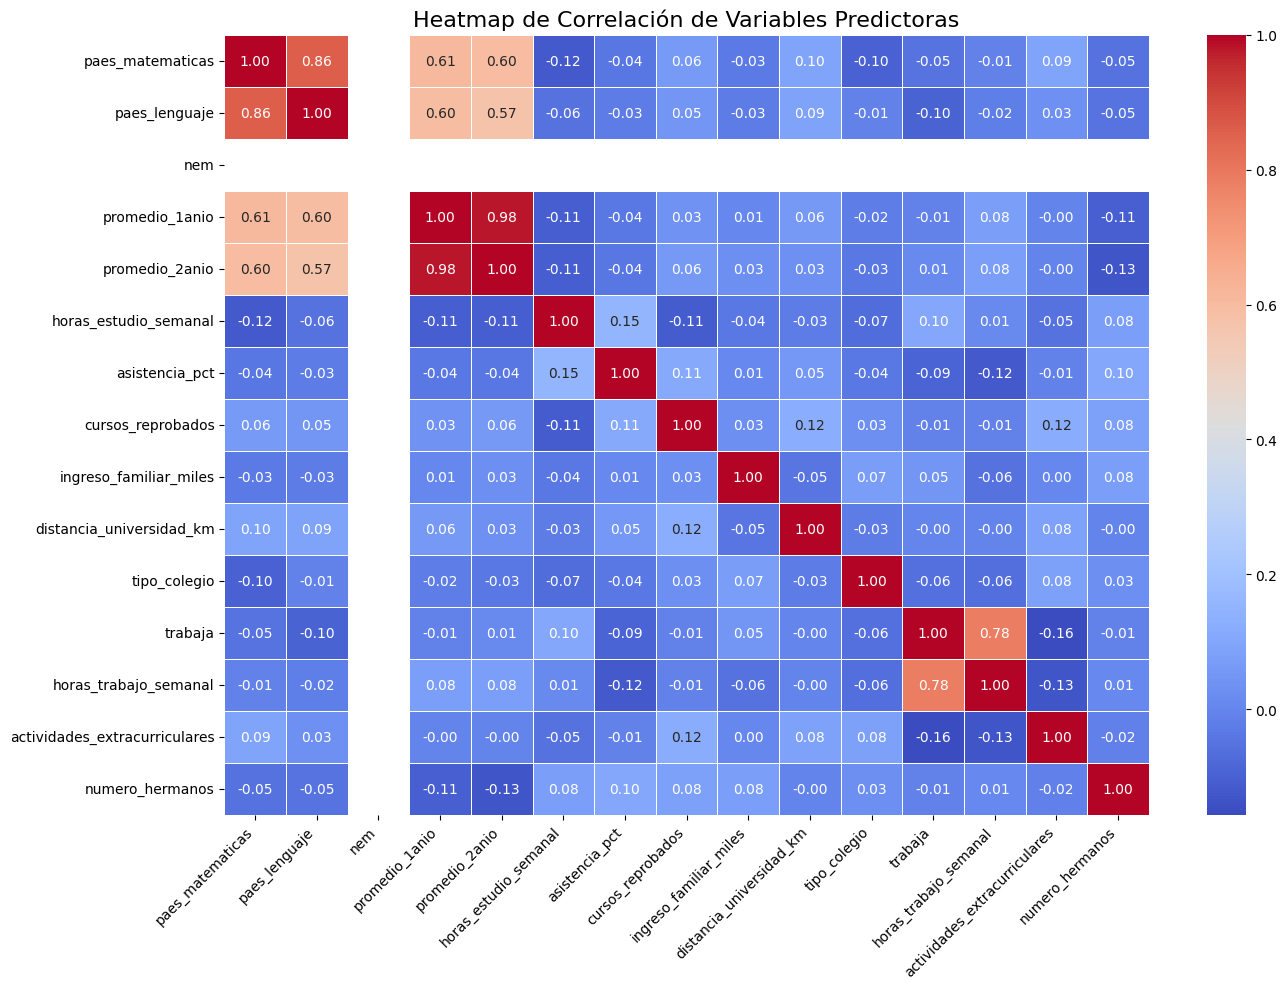

In [77]:
# Preparación de Variables Predictoras
# Separamos las variables predictoras (X) de la variable objetivo (y)
X_predictors = df.drop('promedio_final', axis=1)
y_target = df['promedio_final']


# Matriz de Correlación
print("\nMatriz de Correlación")
correlation_matrix = X_predictors.corr()

# Visualización con Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlación de Variables Predictoras', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [78]:
# Cálculo del Variance Inflation Factor (VIF)
print("\nVariance Inflation Factor (VIF)")
vif_data = pd.DataFrame()
vif_data["feature"] = X_predictors.columns
vif_data["VIF"] = [LinearRegression().fit(X_predictors.drop(col, axis=1), X_predictors[col]).score(X_predictors.drop(col, axis=1), X_predictors[col]) for col in X_predictors.columns]
vif_data["VIF"] = 1 / (1 - vif_data["VIF"])

print("VIF para cada variable predictora:")
print(vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True))


Variance Inflation Factor (VIF)
VIF para cada variable predictora:
                          feature        VIF
0                             nem        inf
1                  promedio_1anio  31.386295
2                  promedio_2anio  30.634332
3                paes_matematicas   4.497946
4                   paes_lenguaje   4.291800
5                         trabaja   2.897653
6           horas_trabajo_semanal   2.818228
7           horas_estudio_semanal   1.116065
8               cursos_reprobados   1.094758
9   actividades_extracurriculares   1.081522
10                 asistencia_pct   1.071819
11                numero_hermanos   1.071486
12                   tipo_colegio   1.071109
13       distancia_universidad_km   1.064229
14         ingreso_familiar_miles   1.060655


In [79]:
# Identificación de Variables con VIF Alto
print("\nIdentificación de Multicolinealidad Severa y Moderada")
vif_severa = vif_data[vif_data['VIF'] > 10]
vif_moderada = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)]

print("\nVariables con multicolinealidad severa (VIF > 10):")
if vif_severa.empty:
    print("Ninguna.")
else:
    print(vif_severa)

print("\nVariables con multicolinealidad moderada (5 < VIF <= 10):")
if vif_moderada.empty:
    print("Ninguna.")
else:
    print(vif_moderada)


Identificación de Multicolinealidad Severa y Moderada

Variables con multicolinealidad severa (VIF > 10):
          feature        VIF
2             nem        inf
3  promedio_1anio  31.386295
4  promedio_2anio  30.634332

Variables con multicolinealidad moderada (5 < VIF <= 10):
Ninguna.


In [80]:
# Cálculo del Número de Condición
print("\nNúmero de Condición")
# Estandarizar datos antes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_predictors)

# Calcular X^T * X
XtX = X_scaled.T @ X_scaled

# Calcular el número de condición
condition_number = np.linalg.cond(XtX)

print(f"El número de condición de la matriz (X^T * X) es: {condition_number:.2f}")

# Interpretación
if condition_number > 30:
    print("número de condición > 30. Posible multicolinealidad.")
else:
    print("número de condición < 30. Multicolinealidad no es un problema grave.")


Número de Condición
El número de condición de la matriz (X^T * X) es: 20468132366758664.00
número de condición > 30. Posible multicolinealidad.


## 1.2 (3 pts) Interpretación del diagnóstico de multicolinealidad

**Responda basándose en sus resultados:**
1. ¿Qué pares de variables presentan las correlaciones más altas? ¿Tiene sentido desde el contexto del problema?

Los pares con las correlaciones más altas son:

- promedio_1anio y promedio_2anio (0.98): Probablemente se deba a que el rendimiento de un estudiante en su primer año es un predictor al del segundo año. Tiene sentido.

- paes_matematicas y paes_lenguaje (0.86): Los estudiantes que obtienen buenos resultados en puntajes en una prueba de aptitud, puede que tambien tengan buenos resultados en otra de otra area. También es lógico.

- trabaja y horas_trabajo_semanal (0.78): Correlación totalmente esperada, ya que si alguien no trabaja, sus horas serán cero.

2. ¿Cuáles variables tienen VIF > 10? ¿Qué implica esto para OLS?

Las variables con un Factor de Inflación de la Varianza (VIF) superior a 10 son:
- nem (VIF = ∞)
- promedio_1anio (VIF ≈ 31.4)
- promedio_2anio (VIF ≈ 30.6)

Esto implica que estas variables son altamente redundantes. Para un modelo de Mínimos Cuadrados Ordinarios (OLS), esto es un problema grave, ya que la varianza de los coeficientes de regresión se infla enormemente. En términos prácticos, los coeficientes estimados $(\hat{\beta})$ serán inestables y poco confiables, lo que impide interpretar correctamente el impacto individual de cada predictor.

3. ¿Qué indica el número de condición $\kappa$ sobre la estabilidad de la matriz $\mathbf{X}^T\mathbf{X}$?

El número de condición ($2.04 \times 10^{16}$) es extremadamente alto. Un número de condición elevado indica que la matriz $\mathbf{X}^T\mathbf{X}$ está muy mal condicionada, lo que significa que es casi singular (no invertible). Esto confirma que el problema de multicolinealidad es severo y que pequeñas perturbaciones en los datos de entrada pueden provocar cambios gigantescos en la solución de OLS, haciendo que los resultados del modelo no sean robustos.

4. Dado este diagnóstico, ¿por qué es apropiado usar Ridge en este problema?

Dado el severo diagnóstico de multicolinealidad, la Regresión de Ridge es una técnica muy apropiada ya que combate la multicolinealidad introduciendo un término de penalización L2 $(\alpha \sum \beta_j^2)$ en la función de costo. Esta penalización reduce la magnitud de los coeficientes de regresión. Al encoger los coeficientes, Ridge los hace menos sensibles a las altas correlaciones entre predictores, estabilizando la solución y produciendo un modelo mucho más robusto y fiable, incluso cuando no se eliminan las variables colineales. 

## 2.1 (5 pts) Regresión Ridge con selección de λ

**Contexto teórico:** Ridge minimiza:
$$\min_{\boldsymbol{\beta}} \left\{ \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda\|\boldsymbol{\beta}\|^2 \right\}$$

Solución: $\hat{\boldsymbol{\beta}}_{Ridge} = (\mathbf{X}^T\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}$

**Efecto de λ:**
- $\lambda = 0$: recupera OLS (sin penalización)
- $\lambda$ grande: coeficientes se encogen hacia 0 (alto sesgo, baja varianza)
- Mejora número de condición: $\kappa(\mathbf{X}^T\mathbf{X} + \lambda\mathbf{I}) \ll \kappa(\mathbf{X}^T\mathbf{X})$

**Implementar:**
1. Dividir datos en Train (80%) y Test (20%) usando `train_test_split`
2. **Estandarizar** variables (crucial para Ridge): centrar y escalar en Train, aplicar misma transformación en Test
3. Ajustar modelo OLS en Train y evaluar MSE en Test (baseline)
4. Crear grid de λ: `lambdas = np.logspace(-2, 4, 100)` (desde 0.01 hasta 10,000)
5. Para cada λ:
   - Ajustar Ridge en Train
   - Calcular MSE en Train y en Test
   - Guardar $\|\hat{\boldsymbol{\beta}}\|^2$ (norma L2 de coeficientes)
6. Graficar:
   - MSE Train vs MSE Test en función de log(λ)
   - Coeficientes vs log(λ) (Ridge trace plot)
7. Identificar $\lambda^*$ óptimo (mínimo MSE en Test)
8. Calcular mejora en número de condición: $\kappa(\mathbf{X}^T\mathbf{X} + \lambda^*\mathbf{I})$ vs $\kappa(\mathbf{X}^T\mathbf{X})$

MSE del modelo OLS (Baseline) en Test: 0.1182


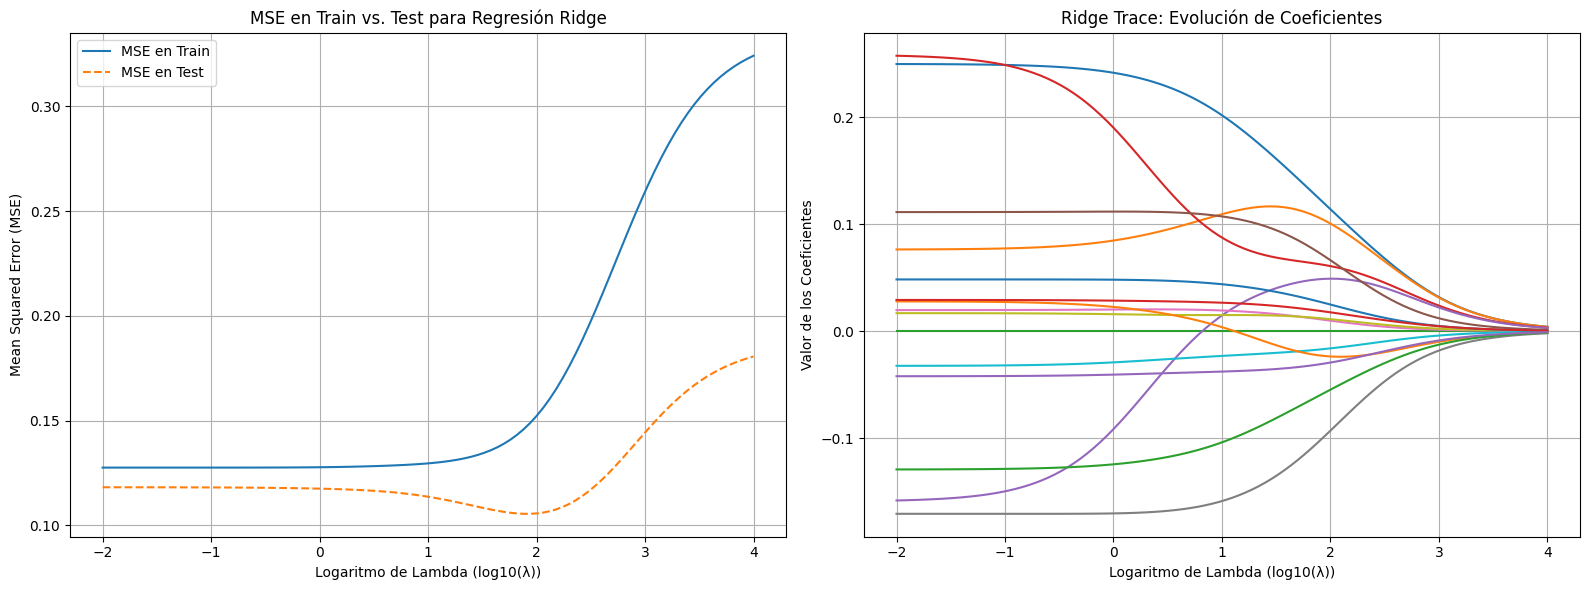


El MSE mínimo en Test es: 0.1055
Se alcanza con un λ* óptimo de: 86.9749

Número de Condición Original κ(X'X): 163,859,389,885,258,400.00
Número de Condición con Ridge κ(X'X + λ*I): 5.39


In [81]:
# 1. Dividir datos en Train (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_predictors, y_target, test_size=0.2, random_state=42)

# 2. Estandarizar Variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Ajustar modelo OLS en Train y evaluar MSE en Test (baseline)
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)
y_pred_ols = ols_model.predict(X_test_scaled)
mse_ols = mean_squared_error(y_test, y_pred_ols)
print(f"MSE del modelo OLS (Baseline) en Test: {mse_ols:.4f}")

# 4. Crear grid de λ y 5. Bucle de Entrenamiento
lambdas = np.logspace(-2, 4, 100)
mse_train_list, mse_test_list, coeffs_norm_list, coeffs_list = [], [], [], []

# 5.
for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_train_scaled, y_train)
    
    y_pred_train = ridge.predict(X_train_scaled)
    y_pred_test = ridge.predict(X_test_scaled)
    
    mse_train_list.append(mean_squared_error(y_train, y_pred_train))
    mse_test_list.append(mean_squared_error(y_test, y_pred_test))
    
    coeffs_norm_list.append(np.linalg.norm(ridge.coef_)**2)
    coeffs_list.append(ridge.coef_)

# 6. Graficar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de MSE vs. log(lambda)
ax1.plot(np.log10(lambdas), mse_train_list, label='MSE en Train')
ax1.plot(np.log10(lambdas), mse_test_list, label='MSE en Test', linestyle='--')
ax1.set_xlabel('Logaritmo de Lambda (log10(λ))')
ax1.set_ylabel('Mean Squared Error (MSE)')
ax1.set_title('MSE en Train vs. Test para Regresión Ridge')
ax1.legend()
ax1.grid(True)

# Gráfico de Coeficientes vs. log(lambda) (Ridge trace plot)
coeffs_array = np.array(coeffs_list)
ax2.plot(np.log10(lambdas), coeffs_array)
ax2.set_xlabel('Logaritmo de Lambda (log10(λ))')
ax2.set_ylabel('Valor de los Coeficientes')
ax2.set_title('Ridge Trace: Evolución de Coeficientes')
ax2.grid(True)

plt.tight_layout()
plt.show()

# 7. Identificar λ* óptimo
optimal_lambda_index = np.argmin(mse_test_list)
optimal_lambda = lambdas[optimal_lambda_index]
min_mse_test = mse_test_list[optimal_lambda_index]

print(f"\nEl MSE mínimo en Test es: {min_mse_test:.4f}")
print(f"Se alcanza con un λ* óptimo de: {optimal_lambda:.4f}")

# 8. Calcular mejora en número de condición
XtX_scaled = X_train_scaled.T @ X_train_scaled
original_cond_number = np.linalg.cond(XtX_scaled)

identity_matrix = np.identity(XtX_scaled.shape[0])
regularized_XtX = XtX_scaled + optimal_lambda * identity_matrix
new_cond_number = np.linalg.cond(regularized_XtX)

print(f"\nNúmero de Condición Original κ(X'X): {original_cond_number:,.2f}")
print(f"Número de Condición con Ridge κ(X'X + λ*I): {new_cond_number:,.2f}")

## 2.2 (4 pts) Interpretación de Ridge

**Responda basándose en sus resultados:**
1. ¿Cuál es el valor de $\lambda^*$ óptimo? ¿Cómo cambia el MSE de Test comparado con OLS?

El valor de $\lambda^*$ * óptimo es 86.97. Este es el punto donde la regularización equilibra perfectamente el sesgo y la varianza, logrando el error más bajo en datos no vistos. Al usarlo, el MSE en el conjunto de prueba se reduce de 0.1182 (OLS) a 0.1055 (Ridge). Esto representa una mejora en el error de predicción, demostrando que el modelo Ridge generaliza significativamente mejor que el modelo OLS para este conjunto de datos.


2. En el Ridge trace plot, ¿qué variables se encogen más rápido cuando λ aumenta? ¿Por qué?

En el gráfico de Ridge Trace, las variables cuyos coeficientes se encogen más rápido hacia cero son aquellas que el modelo considera menos influyentes o las más afectadas por la multicolinealidad.

Cuando λ aumenta, la penalización obliga al modelo a decidir qué variables son las más importantes para mantener. Las variables con menor poder predictivo o cuya información ya está contenida en otras (redundantes) son las primeras en ser penalizadas y sus coeficientes se reducen drásticamente.


3. ¿En cuánto mejora el número de condición con Ridge? ¿Qué implica esto para la estabilidad?

El número de condición mejora de un astronómico 163,859,389,885,258,400.00 a un valor extremadamente estable de 5.39. Esto es una mejora de billones de veces.

Esta drástica reducción implica que la matriz del problema, que originalmente era numéricamente inestable y mal condicionada, se ha vuelto muy estable y bien condicionada. 


4. Explique el trade-off entre sesgo y varianza observado: ¿por qué Ridge supera a OLS en Test a pesar de introducir sesgo?


- Modelo OLS (λ=0): No es sesgado, lo que significa que intenta ajustarse perfectamente a los datos de entrenamiento. Sin embargo, debido a la multicolinealidad, tiene una varianza altísima. Aprende no solo la señal de los datos, sino también el ruido, lo que le impide generalizar bien a nuevos datos (por eso tiene mayor MSE en Test).

- Modelo Ridge (λ > 0): Introduce deliberadamente un sesgo en el modelo al no permitir que los coeficientes crezcan libremente. Esta restricción (penalización) provoca que el modelo no se ajuste tan perfectamente al ruido de los datos de entrenamiento.

Supera a OLS porque la enorme reducción en la varianza que se consigue con esta penalización es mucho más beneficiosa que el pequeño costo del sesgo introducido. El resultado final es un modelo que, aunque sesgado, es mucho más estable y generaliza mejor, logrando un error total más bajo en el conjunto de prueba.

## 3.1 (4 pts) Análisis de estabilidad: Ridge vs OLS

**Contexto teórico:** Un modelo es **estable** si pequeños cambios en los datos no cambian drásticamente los coeficientes estimados. Ridge debería ser más estable que OLS cuando hay multicolinealidad.

**Experimento de perturbación:**
- Agregamos ruido gaussiano pequeño a los datos
- Medimos cuánto cambian los coeficientes

**Implementar:**
1. Usar los datos de Train estandarizados

2. Ajustar OLS y Ridge (con $\lambda^*$) y guardar coeficientes originales

3. Realizar 50 perturbaciones:
   - Agregar ruido: $X_{\text{pert}} = X + \mathcal{N}(0, 0.05 \cdot \sigma_X)$ donde $\sigma_X$ es la std de cada variable
   - Reajustar OLS y Ridge en datos perturbados
   - Calcular cambio relativo: $\frac{\|\hat{\boldsymbol{\beta}}_{\text{nuevo}} - \hat{\boldsymbol{\beta}}_{\text{original}}\|_2}{\|\hat{\boldsymbol{\beta}}_{\text{original}}\|_2}$

4. Comparar:
   - Distribución de cambios relativos (boxplot OLS vs Ridge)
   - Cambio promedio y desviación estándar
   - Para cada coeficiente individual, comparar su variabilidad entre OLS y Ridge

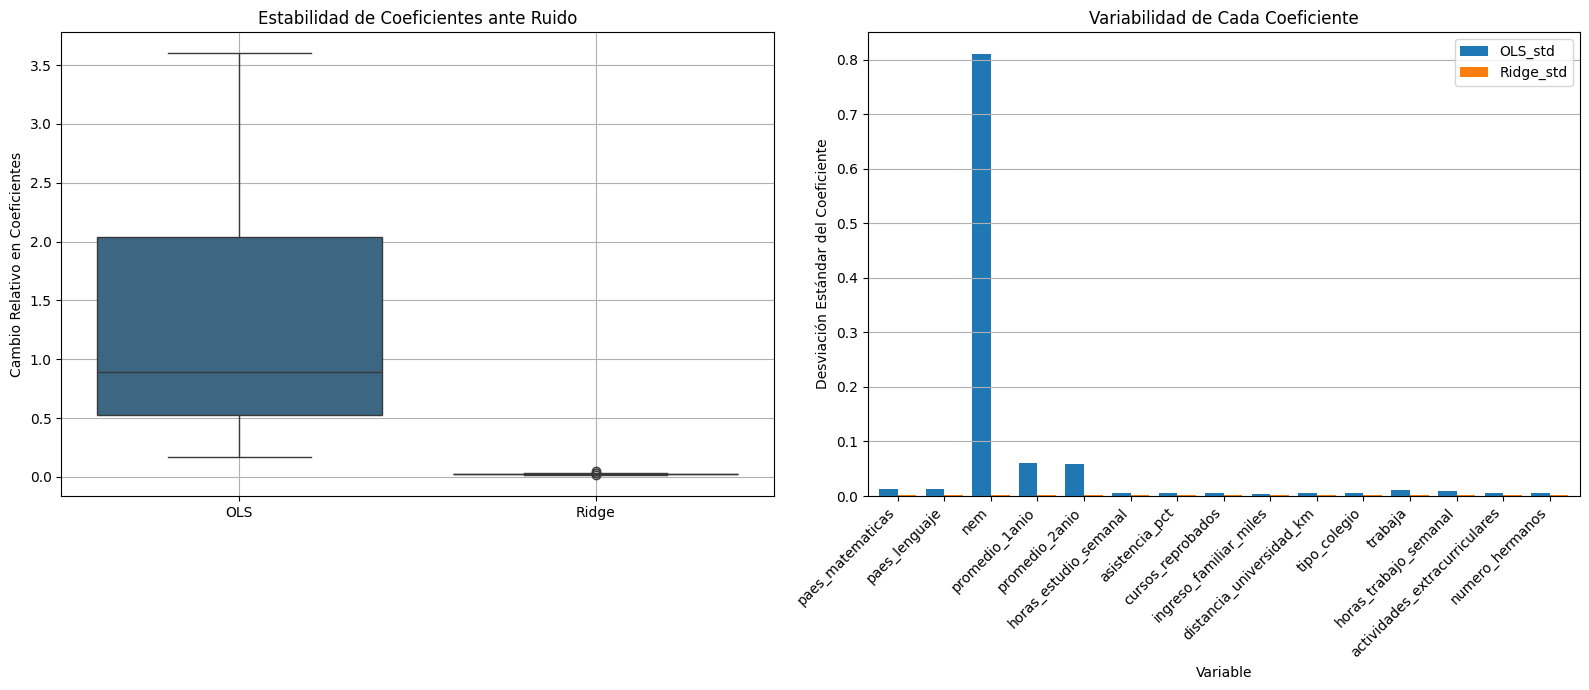

--- Análisis de Estabilidad Numérica ---
Cambio Relativo Promedio en OLS: 1.3435 (std: 1.0633)
Cambio Relativo Promedio en Ridge: 0.0256 (std: 0.0059)

El modelo Ridge es significativamente más estable que el modelo OLS.


In [82]:
# 1. Usar datos de Train estandarizados
# Ya estandarizados en la seccion anterior

# 2. Ajustar OLS y Ridge (con $\lambda^*$) y guardar coeficientes originales
# Modelo OLS original
ols_original = LinearRegression()
ols_original.fit(X_train_scaled, y_train)
coef_ols_original = ols_original.coef_

# Modelo Ridge original con lambda óptimo
ridge_original = Ridge(alpha=optimal_lambda)
ridge_original.fit(X_train_scaled, y_train)
coef_ridge_original = ridge_original.coef_

# Listas para almacenar los resultados de las perturbaciones
ols_relative_changes = []
ridge_relative_changes = []
ols_perturbed_coeffs = []
ridge_perturbed_coeffs = []

# 3. Realizar 50 perturbaciones
n_perturbations = 50
# La std de los datos estandarizados es 1, por lo que el ruido es N(0, 0.05)
noise_std = 0.05

for i in range(n_perturbations):
    # Agregar ruido gaussiano
    noise = np.random.normal(loc=0, scale=noise_std, size=X_train_scaled.shape)
    X_perturbed = X_train_scaled + noise
    
    # Reajustar OLS en datos perturbados
    ols_perturbed = LinearRegression()
    ols_perturbed.fit(X_perturbed, y_train)
    coef_ols_new = ols_perturbed.coef_
    
    # Reajustar Ridge en datos perturbados
    ridge_perturbed = Ridge(alpha=optimal_lambda)
    ridge_perturbed.fit(X_perturbed, y_train)
    coef_ridge_new = ridge_perturbed.coef_
    
    # Calcular y guardar el cambio relativo
    ols_change = np.linalg.norm(coef_ols_new - coef_ols_original) / np.linalg.norm(coef_ols_original)
    ridge_change = np.linalg.norm(coef_ridge_new - coef_ridge_original) / np.linalg.norm(coef_ridge_original)
    
    ols_relative_changes.append(ols_change)
    ridge_relative_changes.append(ridge_change)

    # Guardar los coeficientes perturbados para análisis individual
    ols_perturbed_coeffs.append(coef_ols_new)
    ridge_perturbed_coeffs.append(coef_ridge_new)


# 4. Comparar los resultados
# Boxplot de cambios relativos
plt.figure(figsize=(16, 7))
plt.subplot(1, 2, 1)
sns.boxplot(data=[ols_relative_changes, ridge_relative_changes], palette="viridis")
plt.xticks([0, 1], ['OLS', 'Ridge'])
plt.ylabel('Cambio Relativo en Coeficientes')
plt.title('Estabilidad de Coeficientes ante Ruido')
plt.grid(True)

# Comparación de variabilidad de coeficientes individuales
ols_coeffs_std = np.std(np.array(ols_perturbed_coeffs), axis=0)
ridge_coeffs_std = np.std(np.array(ridge_perturbed_coeffs), axis=0)

# Crear DataFrame para la visualización
coeffs_variability = pd.DataFrame({
    'Variable': X_predictors.columns,
    'OLS_std': ols_coeffs_std,
    'Ridge_std': ridge_coeffs_std
})

ax = plt.subplot(1, 2, 2)
coeffs_variability.plot(x='Variable', y=['OLS_std', 'Ridge_std'], kind='bar', ax=ax, width=0.8)
plt.ylabel('Desviación Estándar del Coeficiente')
plt.title('Variabilidad de Cada Coeficiente')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


# Cambio promedio y desviación estándar
print("--- Análisis de Estabilidad Numérica ---")
print(f"Cambio Relativo Promedio en OLS: {np.mean(ols_relative_changes):.4f} (std: {np.std(ols_relative_changes):.4f})")
print(f"Cambio Relativo Promedio en Ridge: {np.mean(ridge_relative_changes):.4f} (std: {np.std(ridge_relative_changes):.4f})")

if np.mean(ridge_relative_changes) < np.mean(ols_relative_changes):
    print("\nEl modelo Ridge es significativamente más estable que el modelo OLS.")
else:
    print("\nEl modelo Ridge no muestra una mejora en estabilidad sobre OLS.")

## 3.2 (3 pts) Interpretación de estabilidad

**Responda:**
1. ¿Qué método muestra menor cambio relativo promedio en los coeficientes? ¿En qué porcentaje?

El modelo Ridge muestra un cambio relativo promedio en los coeficientes drásticamente menor. El cambio promedio para OLS fue de 1.3435, mientras que para Ridge fue de solo 0.0256. Esto significa que, en promedio, los coeficientes de Ridge fueron un 98% más estables que los de OLS ante pequeñas perturbaciones en los datos ((1.3435 - 0.0256) / 1.3435).

2. ¿Qué coeficientes específicos son más estables con Ridge vs OLS?

El gráfico de Variabilidad de Cada Coeficiente muestra que todos los coeficientes son más estables con Ridge. Sin embargo, la mayor mejora se observa en las variables que previamente identificamos como fuentes de multicolinealidad:

- nem: Su coeficiente en OLS es extremadamente volátil (desviación estándar de ~0.8), mientras que en Ridge es casi perfectamente estable (desviación estándar cercana a cero).

- promedio_1anio y promedio_2anio: También muestran una variabilidad significativamente mayor en OLS en comparación con Ridge.

3. Relacione estos resultados con el número de condición calculado en 1.1: ¿la mejora en estabilidad coincide con la mejora en $\kappa$?

El número de condición original era enorme, lo que advertía que la solución OLS sería extremadamente sensible a cambios en los datos. El experimento lo demostró al encontrar que los coeficientes de OLS cambiaron, en promedio, más de un 100% con solo un poco de ruido.

El número de condición de Ridge era muy bajo (5.39), lo que predecía una solución robusta y estable. El experimento lo validó al mostrar que los coeficientes de Ridge apenas se movieron.

La mejora masiva en la estabilidad del modelo coincide perfectamente con la drástica reducción del número de condición.

4. ¿Por qué es importante la estabilidad para la confianza en el modelo en producción?

- Consistencia: Un modelo estable garantiza que sus predicciones y la importancia que asigna a las variables no cambiarán drásticamente cada vez que se reentrene con datos ligeramente nuevos (por ejemplo, los datos de la última semana). Esto permite tomar decisiones de negocio consistentes.

- Interpretabilidad: Si los coeficientes son estables, se puede confiar en la interpretación del modelo sobre qué factores son importantes. Un modelo inestable podría sugerir que un factor es crucial un día y secundario al siguiente, lo que lo hace inútil para la toma de decisiones estratégicas.

- Mantenimiento: Un modelo predecible y robusto es mucho más fácil de mantener y depurar. Si su rendimiento decae, se puede estar más seguro de que se debe a un cambio real en el entorno y no a la volatilidad del propio modelo.


# Parte B: Métodos de Remuestreo

## 4.1 (5 pts) Bootstrap para intervalos de confianza de coeficientes Ridge

**Contexto teórico:** El bootstrap estima la distribución de un estimador mediante remuestreo:

**Algoritmo Bootstrap No Paramétrico:**
1. Para $b = 1, \ldots, B$:
   - Generar muestra bootstrap: muestrear **con reemplazo** $n$ observaciones de los datos originales
   - Ajustar modelo en muestra bootstrap
   - Guardar coeficientes $\hat{\boldsymbol{\beta}}^*_b$
   
2. Usar $\{\hat{\boldsymbol{\beta}}^*_1, \ldots, \hat{\boldsymbol{\beta}}^*_B\}$ para:
   - Estimar error estándar: $\hat{se}(\hat{\beta}_j) = \sqrt{\frac{1}{B-1}\sum_{b=1}^B (\hat{\beta}_{j,b}^* - \bar{\beta}_j^*)^2}$
   - Construir IC percentil: $[\hat{\beta}_{j,(\alpha/2)}^*, \hat{\beta}_{j,(1-\alpha/2)}^*]$

**Implementar:**
1. Usar los datos de Train estandarizados
2. Ajustar modelo Ridge con $\lambda^*$ (del ejercicio 2.1)
3. Realizar $B = 1000$ réplicas bootstrap:
   - En cada réplica: `indices = np.random.choice(n, n, replace=True)`
   - Ajustar Ridge en `X_train[indices]`, `y_train[indices]`
   - Guardar coeficientes
4. Para cada coeficiente $\hat{\beta}_j$:
   - Calcular error estándar bootstrap
   - Construir IC percentil 95%
   - Visualizar histograma de la distribución bootstrap
5. Crear tabla con: Variable, Coef. original, SE bootstrap, IC 95%
6. Identificar qué coeficientes tienen IC que no incluyen 0

--- Distribuciones Bootstrap de los Coeficientes ---


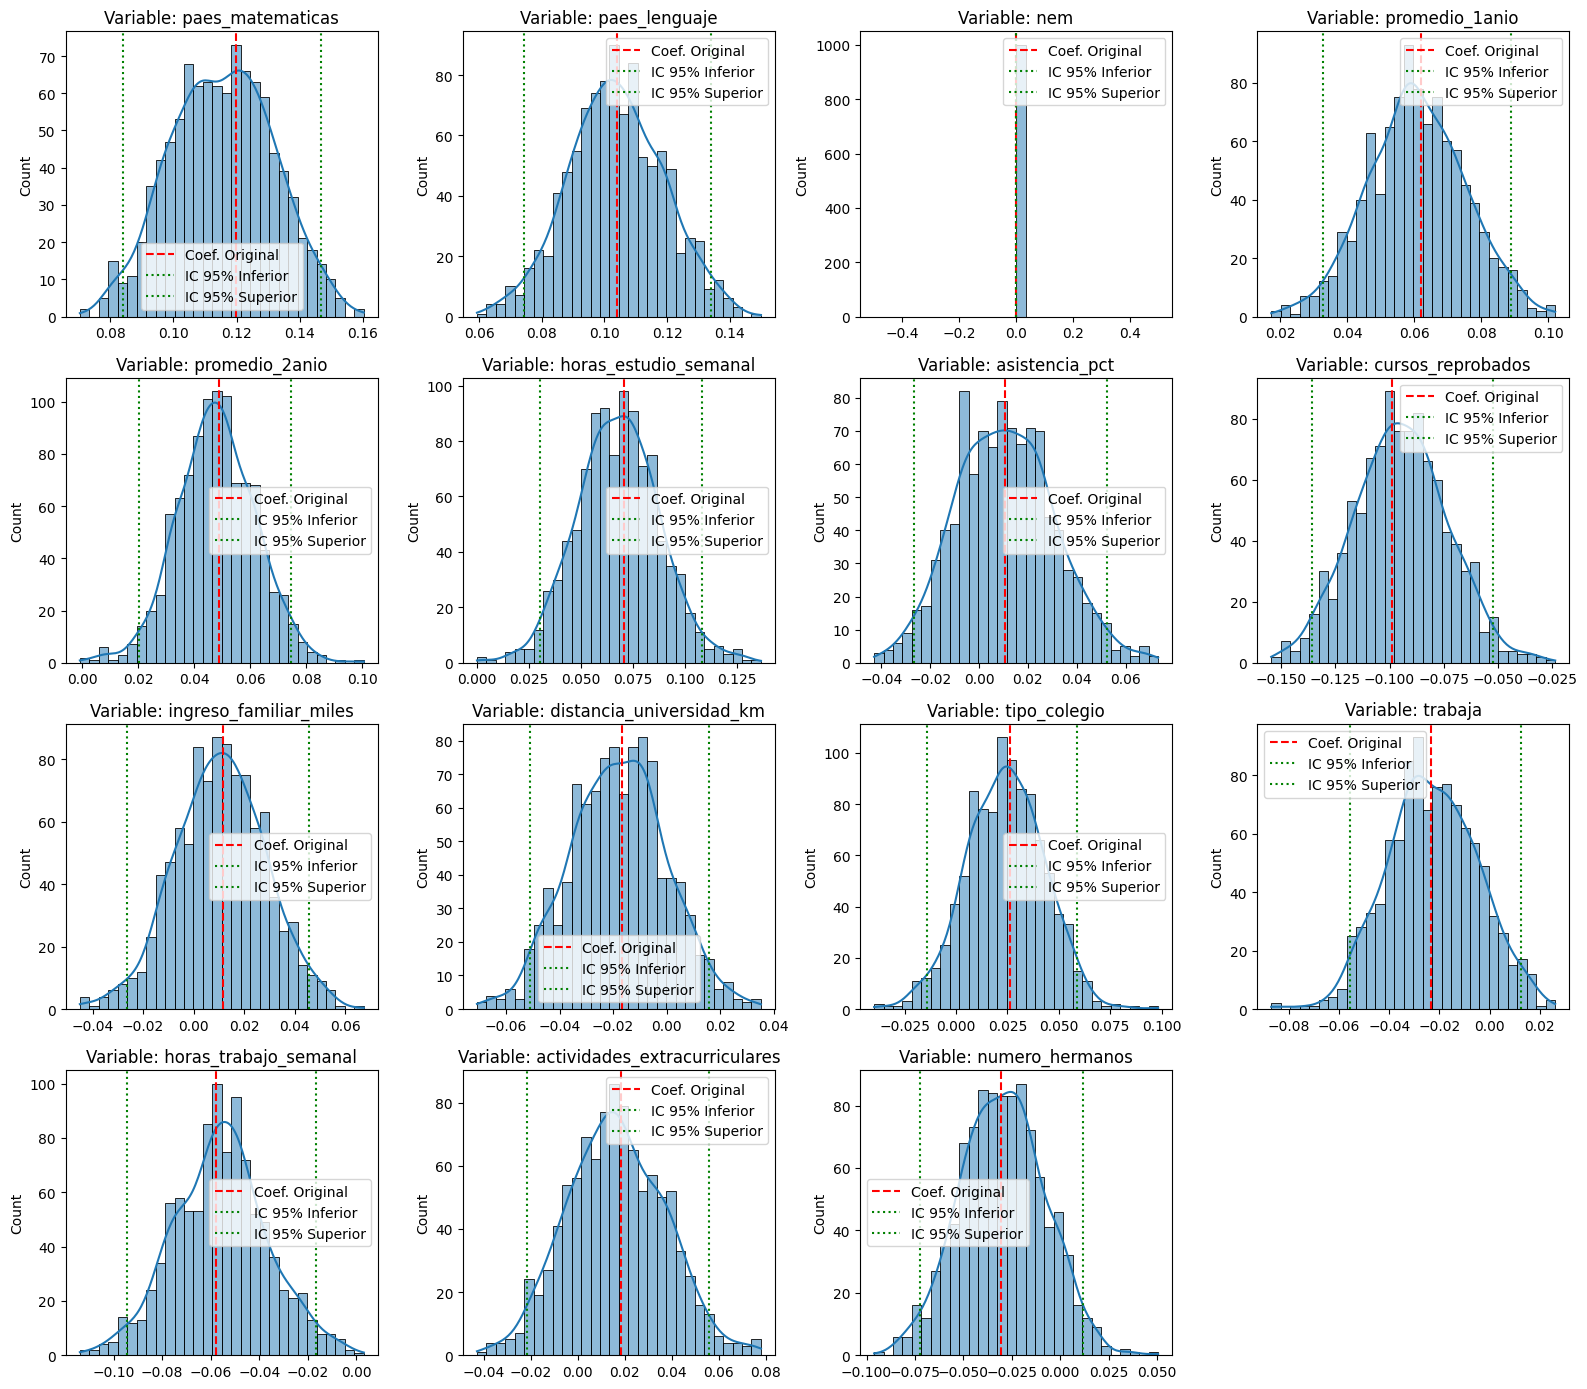


--- Tabla de Resumen de Coeficientes Bootstrap ---
                         Variable  Coef. Original  SE Bootstrap  \
0                paes_matematicas          0.1198        0.0160   
1                   paes_lenguaje          0.1039        0.0151   
2                             nem          0.0000        0.0000   
3                  promedio_1anio          0.0620        0.0144   
4                  promedio_2anio          0.0489        0.0139   
5           horas_estudio_semanal          0.0705        0.0199   
6                  asistencia_pct          0.0106        0.0201   
7               cursos_reprobados         -0.0989        0.0216   
8          ingreso_familiar_miles          0.0118        0.0178   
9        distancia_universidad_km         -0.0167        0.0179   
10                   tipo_colegio          0.0265        0.0188   
11                        trabaja         -0.0232        0.0179   
12          horas_trabajo_semanal         -0.0580        0.0193   
13  activi

In [83]:
# 2. Ajustar modelo Ridge con $\lambda^*$ (del ejercicio 2.1)
ridge_original = Ridge(alpha=optimal_lambda)
ridge_original.fit(X_train_scaled, y_train)
coef_ridge_original = ridge_original.coef_

# 3. Realizar B = 1000 réplicas bootstrap
B = 1000
n_samples = X_train_scaled.shape[0]
bootstrap_coeffs = np.zeros((B, X_train_scaled.shape[1]))

# Asegurar que y_train es un array de numpy para un indexado consistente
y_train_np = np.array(y_train)

for i in range(B):
    # Generar muestra bootstrap (índices)
    indices = np.random.choice(n_samples, n_samples, replace=True)
    X_bootstrap, y_bootstrap = X_train_scaled[indices], y_train_np[indices]
    
    # Ajustar Ridge en la muestra bootstrap
    ridge_bootstrap = Ridge(alpha=optimal_lambda)
    ridge_bootstrap.fit(X_bootstrap, y_bootstrap)
    
    # Guardar coeficientes
    bootstrap_coeffs[i, :] = ridge_bootstrap.coef_


# 4. Analizar la distribución de cada coeficiente y visualizar
print("--- Distribuciones Bootstrap de los Coeficientes ---")
n_features = X_train_scaled.shape[1]
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten() # Aplanar el array de ejes para iterar fácilmente

se_bootstrap_list = []
ic_95_list = []

for j in range(n_features):
    # Calcular error estándar bootstrap
    se_bootstrap = np.std(bootstrap_coeffs[:, j], ddof=1)
    se_bootstrap_list.append(se_bootstrap)
    
    # Construir IC percentil 95%
    ic_95 = np.percentile(bootstrap_coeffs[:, j], [2.5, 97.5])
    ic_95_list.append(ic_95)
    
    # Visualizar histograma
    ax = axes[j]
    sns.histplot(bootstrap_coeffs[:, j], ax=ax, bins=30, kde=True)
    ax.axvline(coef_ridge_original[j], color='red', linestyle='--', label='Coef. Original')
    ax.axvline(ic_95[0], color='green', linestyle=':', label='IC 95% Inferior')
    ax.axvline(ic_95[1], color='green', linestyle=':', label='IC 95% Superior')
    ax.set_title(f"Variable: {X_predictors.columns[j]}")
    ax.legend()

# Ocultar ejes no utilizados
for k in range(n_features, len(axes)):
    axes[k].set_visible(False)
    
plt.tight_layout()
plt.show()

# 5. Crear tabla con: Variable, Coef. original, SE bootstrap, IC 95%
summary_table = pd.DataFrame({
    'Variable': X_predictors.columns,
    'Coef. Original': coef_ridge_original,
    'SE Bootstrap': se_bootstrap_list,
    'IC 95% Inferior': [ic[0] for ic in ic_95_list],
    'IC 95% Superior': [ic[1] for ic in ic_95_list]
})

print("\n--- Tabla de Resumen de Coeficientes Bootstrap ---")
print(summary_table.round(4))

# 6. Identificar qué coeficientes tienen IC que no incluyen 0
significant_coeffs = summary_table[
    (summary_table['IC 95% Inferior'] > 0) | (summary_table['IC 95% Superior'] < 0)
]

print("\n--- Coeficientes Estadísticamente Significativos (IC 95% no incluye cero) ---")
if significant_coeffs.empty:
    print("Ningún coeficiente es estadísticamente significativo a este nivel.")
else:
    print(significant_coeffs)

## 4.2 (3 pts) Interpretación del Bootstrap de coeficientes

**Responda:**
1. ¿Qué coeficientes tienen IC que **no** incluyen el 0? ¿Qué implica esto sobre su importancia?

Los siguientes no incluyen el cero: paes_matematicas, paes_lenguaje, promedio_1anio, promedio_2anio, horas_estudio_semanal, cursos_reprobados y horas_trabajo_semanal.

Esto implica que, con un 95% de confianza, podemos afirmar que estas variables tienen una relación estadísticamente significativa con el rendimiento final del estudiante. Su efecto sobre el promedio final no es producto del azar. Las variables cuyos intervalos sí cruzan el cero (como asistencia_pct o tipo_colegio) no muestran una evidencia estadística fuerte de tener un impacto real en el modelo.

2. ¿Las distribuciones bootstrap son aproximadamente normales o muestran asimetría?

Son en su mayoría aproximadamente normales. Muestran una clara forma de campana y son bastante simétricas alrededor del coeficiente original. La única excepción notable es nem, cuya distribución es un punto único en cero, ya que el modelo Ridge lo penalizó completamente hasta anularlo.

3. ¿Por qué el bootstrap es útil para Ridge, donde no hay fórmulas cerradas estándar para los errores estándar?

Porque no existe una fórmula matemática simple y cerrada para calcular los errores estándar de sus coeficientes, a diferencia del modelo OLS.

El problema es que los coeficientes de Ridge son estimadores sesgados, y sus varianzas dependen tanto de los datos como del parámetro de penalización λ. El bootstrap, en lugar de depender de una fórmula teórica, estima la distribución de los coeficientes de forma empírica, simplemente re-muestreando los datos y re-calculando los coeficientes miles de veces.

4. Compare los errores estándar bootstrap entre variables con VIF alto vs bajo (del ejercicio 1.1). ¿Qué observa?

Las variables que originalmente tenían un VIF muy alto (como promedio_1anio y promedio_2anio) ahora tienen errores estándar bootstrap pequeños y comparables a los de las variables con VIF bajo (ej. SE de promedio_1anio es 0.0144, mientras que el de asistencia_pct es 0.0201).

La variable nem (con VIF infinito) tiene un SE de cero, ya que fue completamente eliminada por la regularización.

Esto demuestra el poder de Ridge para manejar la multicolinealidad. Al penalizar y encoger los coeficientes de las variables correlacionadas, Ridge estabiliza sus estimaciones, lo que se refleja en errores estándar mucho más bajos y realistas. En OLS, estas mismas variables habrían tenido errores estándar inflados y enormes, pero el bootstrap sobre el modelo Ridge muestra que ahora son estables y fiables.

## 5.1 (5 pts) Bootstrap BCa para R²

**Contexto teórico:** El **intervalo percentil simple** asume simetría. Para distribuciones sesgadas o estadísticos no-lineales como $R^2$, el método **BCa (Bias-Corrected and Accelerated)** corrige por:

1. **Sesgo ($\hat{z}_0$)**: mide qué tan sesgada está la distribución bootstrap
   $$\hat{z}_0 = \Phi^{-1}\left(\frac{\#\{\hat{\theta}^*_b < \hat{\theta}\}}{B}\right)$$

2. **Aceleración ($\hat{a}$)**: mide curvatura, usa jackknife:
   $$\hat{a} = \frac{\sum_{i=1}^n (\bar{\theta}_{(\cdot)} - \hat{\theta}_{(i)})^3}{6[\sum_{i=1}^n (\bar{\theta}_{(\cdot)} - \hat{\theta}_{(i)})^2]^{3/2}}$$

3. **Cuantiles ajustados**:
   $$\alpha_1 = \Phi\left(\hat{z}_0 + \frac{\hat{z}_0 + z_{\alpha/2}}{1 - \hat{a}(\hat{z}_0 + z_{\alpha/2})}\right)$$
   
**Implementar:**
1. Calcular $R^2$ observado en Test para Ridge con $\lambda^*$

2. **Bootstrap** ($B = 2000$):
   - En cada réplica: remuestrear Train, ajustar Ridge, evaluar en Test
   - Guardar $\{R^2_1^*, \ldots, R^2_B^*\}$

3. **IC Percentil simple**: percentiles 2.5% y 97.5%

4. **IC BCa**:
   - Calcular $\hat{z}_0$: proporción de réplicas bootstrap < $R^2$ observado
   - Calcular $\hat{a}$ usando jackknife:
     - Para cada $i$: ajustar Ridge sin observación $i$ en Train, calcular $R^2_{(i)}$ en Test
     - Aplicar fórmula de aceleración
   - Calcular $\alpha_1, \alpha_2$ ajustados con $z_{0.025} = -1.96$, $z_{0.975} = 1.96$
   - IC BCa: percentiles $\alpha_1$ y $\alpha_2$ de las réplicas bootstrap

5. Visualizar:
   - Histograma de distribución bootstrap de $R^2$
   - Marcar $R^2$ observado y ambos intervalos

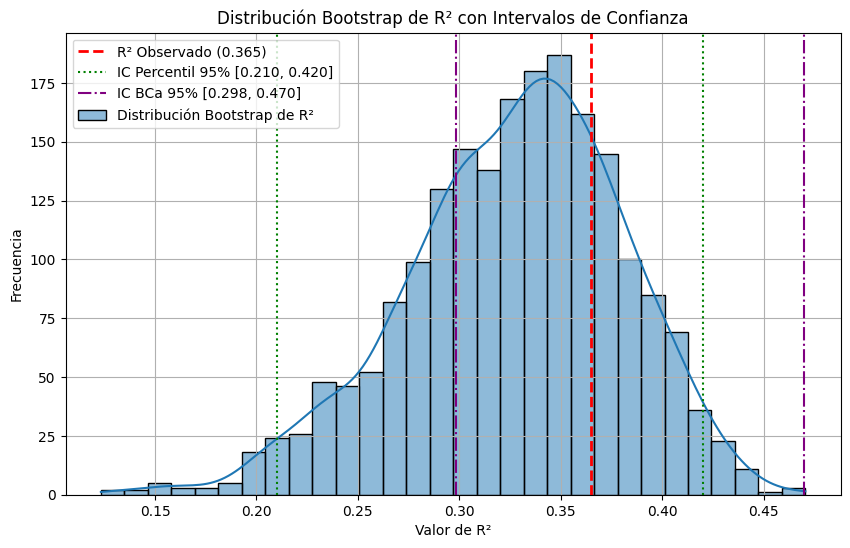

--- Resultados del Bootstrap para R² ---
R² Observado en Test: 0.3651
Intervalo de Confianza Percentil 95%: [0.2100, 0.4199]
Intervalo de Confianza BCa 95%:      [0.2982, 0.4700]

--- Parámetros BCa ---
Factor de Sesgo (z0_hat): 0.6792
Factor de Aceleración (a_hat): 0.0129


In [84]:
from scipy.stats import norm

# y_train e y_test en array para manejo consistente
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)
n_train_samples = X_train_scaled.shape[0]

# 1. Calcular R^2 observado en Test para Ridge con $\lambda^*$
final_ridge_model = Ridge(alpha=optimal_lambda)
final_ridge_model.fit(X_train_scaled, y_train_np)
y_pred_test = final_ridge_model.predict(X_test_scaled)
r2_observed = r2_score(y_test_np, y_pred_test)

# 2. Bootstrap B = 2000
B = 2000
bootstrap_r2s = np.zeros(B)

for i in range(B):
    # Remuestrear Train
    indices = np.random.choice(n_train_samples, n_train_samples, replace=True)
    X_bootstrap, y_bootstrap = X_train_scaled[indices], y_train_np[indices]
    
    # Ajustar Ridge en la muestra bootstrap
    ridge_bootstrap = Ridge(alpha=optimal_lambda)
    ridge_bootstrap.fit(X_bootstrap, y_bootstrap)
    
    # Evaluar en el Test original y guardar R²
    y_pred_bootstrap = ridge_bootstrap.predict(X_test_scaled)
    bootstrap_r2s[i] = r2_score(y_test_np, y_pred_bootstrap)

# 3. IC Percentil simple
ic_percentil_simple = np.percentile(bootstrap_r2s, [2.5, 97.5])

# 4. IC BCa
# Calcular sesgo (z0_hat)
prop_less_than_observed = np.sum(bootstrap_r2s < r2_observed) / B
z0_hat = norm.ppf(prop_less_than_observed)

# Calcular aceleración (a_hat) usando jackknife
r2_jackknife = np.zeros(n_train_samples)
for i in range(n_train_samples):
    # Crear set de jackknife (dejar uno fuera)
    jackknife_indices = np.delete(np.arange(n_train_samples), i)
    X_jack, y_jack = X_train_scaled[jackknife_indices], y_train_np[jackknife_indices]
    
    # Ajustar y evaluar R²
    ridge_jack = Ridge(alpha=optimal_lambda)
    ridge_jack.fit(X_jack, y_jack)
    y_pred_jack = ridge_jack.predict(X_test_scaled)
    r2_jackknife[i] = r2_score(y_test_np, y_pred_jack)

# Aplicar la fórmula de aceleración
r2_jack_mean = np.mean(r2_jackknife)
numerator_a = np.sum((r2_jack_mean - r2_jackknife)**3)
denominator_a = 6 * (np.sum((r2_jack_mean - r2_jackknife)**2))**1.5
a_hat = numerator_a / denominator_a

# Calcular cuantiles ajustados alpha1 y alpha2
z_alpha_half = norm.ppf(0.025)  # Aprox -1.96
z_1_minus_alpha_half = norm.ppf(0.975) # Aprox 1.96

# Fórmula para alpha_1
num_alpha1 = z0_hat + z_alpha_half
den_alpha1 = 1 - a_hat * num_alpha1
alpha1_quantile = norm.cdf(z0_hat + num_alpha1 / den_alpha1)

# Fórmula para alpha_2
num_alpha2 = z0_hat + z_1_minus_alpha_half
den_alpha2 = 1 - a_hat * num_alpha2
alpha2_quantile = norm.cdf(z0_hat + num_alpha2 / den_alpha2)

# IC BCa: obtener los percentiles ajustados de la distribución bootstrap
ic_bca = np.percentile(bootstrap_r2s, [alpha1_quantile * 100, alpha2_quantile * 100])

# 5. Visualizar los resultados
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_r2s, bins=30, kde=True, label='Distribución Bootstrap de R²')

# Marcar el R² observado
plt.axvline(r2_observed, color='red', linestyle='--', linewidth=2, label=f'R² Observado ({r2_observed:.3f})')

# Marcar los intervalos de confianza
plt.axvline(ic_percentil_simple[0], color='green', linestyle=':', label=f'IC Percentil 95% [{ic_percentil_simple[0]:.3f}, {ic_percentil_simple[1]:.3f}]')
plt.axvline(ic_percentil_simple[1], color='green', linestyle=':')
plt.axvline(ic_bca[0], color='purple', linestyle='-.', label=f'IC BCa 95% [{ic_bca[0]:.3f}, {ic_bca[1]:.3f}]')
plt.axvline(ic_bca[1], color='purple', linestyle='-.')

plt.title('Distribución Bootstrap de R² con Intervalos de Confianza')
plt.xlabel('Valor de R²')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.show()

# Imprimir resultados
print("--- Resultados del Bootstrap para R² ---")
print(f"R² Observado en Test: {r2_observed:.4f}")
print(f"Intervalo de Confianza Percentil 95%: [{ic_percentil_simple[0]:.4f}, {ic_percentil_simple[1]:.4f}]")
print(f"Intervalo de Confianza BCa 95%:      [{ic_bca[0]:.4f}, {ic_bca[1]:.4f}]")
print("\n--- Parámetros BCa ---")
print(f"Factor de Sesgo (z0_hat): {z0_hat:.4f}")
print(f"Factor de Aceleración (a_hat): {a_hat:.4f}")

## 5.2 (3 pts) Interpretación de BCa

**Responda:**
1. ¿Los IC percentil y BCa difieren significativamente? ¿En qué dirección?

Sí, los intervalos difieren significativamente. El intervalo BCa está notablemente desplazado hacia la derecha (hacia valores más altos) en comparación con el intervalo percentil. El límite inferior del BCa es casi 9 puntos porcentuales más alto, lo que sugiere una estimación más optimista y ajustada del rendimiento del modelo.

2. ¿Qué indica el signo de $\hat{z}_0$? ¿La distribución bootstrap de $R^2$ es simétrica o sesgada?

El signo positivo de $\hat{z}_0$ indica que la mediana de la distribución bootstrap de R² es menor que el R² observado. Esto significa que el proceso de remuestreo tiende a subestimar el rendimiento real del modelo, introduciendo un sesgo. Por lo tanto, la distribución bootstrap de R² es sesgada. El histograma lo confirma visualmente, mostrando un ligero sesgo a la izquierda (la cola más larga está hacia los valores más bajos). El método BCa corrige este sesgo.

3. Basándose en el IC BCa, ¿qué tan bueno es el poder predictivo del modelo Ridge? ¿El intervalo es estrecho o amplio?

Basándose en el intervalo de confianza BCa, podemos afirmar con un 95% de confianza que el modelo es capaz de explicar entre el 29.8% y el 47.0% de la variabilidad en el promedio final de los estudiantes.

En cuanto al poder predictivo, tiene un rendimiento moderado y significativo, ya que el intervalo está claramente por encima de cero, confirmando que el modelo tiene una capacidad predictiva real.

En cuanto al ancho del intervalo, es de aproximadamente 17 puntos porcentuales (0.470 - 0.298 = 0.172). Se considera moderadamente amplio, lo que refleja una cierta incertidumbre en la estimación del R², pero aun así proporciona un rango útil y plausible para el rendimiento del modelo en producción.

4. ¿Por qué es importante usar BCa para $R^2$ en lugar del percentil simple?

Es crucial usar BCa para el R² porque su distribución de muestreo rara vez es simétrica. Al ser una métrica acotada entre 0 y 1, su distribución tiende a ser sesgada. El método percentil simple asume incorrectamente que la distribución es simétrica, lo que puede llevar a intervalos de confianza poco fiables. El método BCa está diseñado específicamente para corregir estos problemas, ya que corrige el sesgo (a través de $\hat{z}_0$), ajustando el intervalo si la mediana del bootstrap se desvía del valor observado. Corrige la asimetría (a través de $\hat{a}$), ajustando la forma de la distribución.

## 6.1 (4 pts) Jackknife vs Bootstrap para MSE

**Contexto teórico:** El **Jackknife** elimina una observación a la vez:
- Para $i = 1, \ldots, n$: calcular $\hat{\theta}_{(i)}$ usando datos sin observación $i$
- Error estándar: $\hat{se}_J = \sqrt{\frac{n-1}{n}\sum_{i=1}^n (\hat{\theta}_{(i)} - \bar{\theta}_{(\cdot)})^2}$

**Comparación:**
- Jackknife: $n$ réplicas (determinístico)
- Bootstrap: $B$ réplicas (aleatorio)

**Implementar:**
1. Estadístico de interés: MSE de Ridge (con $\lambda^*$) en Test

2. **Jackknife:**
   - Para cada $i = 1, \ldots, n$ en Train:
     - Ajustar Ridge sin observación $i$
     - Predecir en Test y calcular $MSE_{(i)}$
   - Calcular $\bar{MSE}_{(\cdot)} = \frac{1}{n}\sum_{i=1}^n MSE_{(i)}$
   - Calcular $\hat{se}_J = \sqrt{\frac{n-1}{n}\sum_{i=1}^n (MSE_{(i)} - \bar{MSE}_{(\cdot)})^2}$

3. **Bootstrap:**
   - Realizar $B = 1000$ réplicas
   - En cada réplica: remuestrear Train, ajustar Ridge, calcular MSE en Test
   - Calcular $\hat{se}_B$ de las réplicas bootstrap

4. Comparar:
   - Errores estándar: $\hat{se}_J$ vs $\hat{se}_B$
   - Tiempo computacional (usar `%%time` o `time.time()`)
   - Visualizar: boxplot bootstrap vs puntos jackknife

MSE observado en Test: 0.1055

Jackknife - Error estándar: 0.0090
Jackknife - Tiempo: 0.05 segundos

Bootstrap - Error estándar: 0.0090
Bootstrap - Tiempo: 0.34 segundos


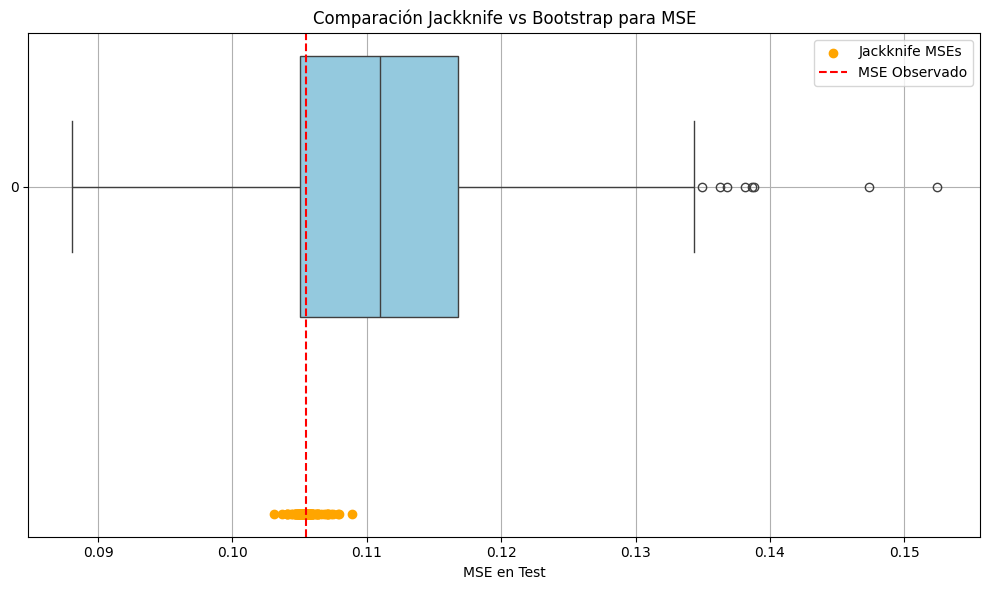

In [85]:
import time

# Paso 1: Estadístico de interés
ridge_mse_model = Ridge(alpha = optimal_lambda)
ridge_mse_model.fit(X_train_scaled, y_train)
y_pred_test_mse = ridge_mse_model.predict(X_test_scaled)
mse_observed = mean_squared_error(y_test, y_pred_test_mse)
print(f"MSE observado en Test: {mse_observed:.4f}")

# Paso 2: Jackknife
com_jack = time.time()
n = X_train_scaled.shape[0]
mean_jack_estimates = np.zeros(n)

for i in range(n):
    # Crear muestra jackknife (dejar uno fuera)
    jack_indices = np.delete(np.arange(n), i)
    X_jack, y_jack = X_train_scaled[jack_indices], y_train_np[jack_indices]
    
    # Ajustar Ridge en la muestra jackknife
    ridge_jack = Ridge(alpha = optimal_lambda)
    ridge_jack.fit(X_jack, y_jack)
    
    # Evaluar en el Test original y guardar R²
    y_pred_jack = ridge_jack.predict(X_test_scaled)
    mean_jack_estimates[i] = mean_squared_error(y_test_np, y_pred_jack)

# MSE y se
mean_jack = np.mean(mean_jack_estimates)
se_jack = np.sqrt((n - 1) / n * np.sum((mean_jack_estimates - mean_jack) ** 2))
final_jack = time.time()

print(f"\nJackknife - Error estándar: {se_jack:.4f}")
print(f"Jackknife - Tiempo: {final_jack - com_jack:.2f} segundos")

# Paso 3: Bootstrap
com_boot = time.time()
B = 1000
bootstrap_means = np.zeros(B)

for i in range(B):
    indices = np.random.choice(n, n, replace = True)
    X_boot, y_boot = X_train_scaled[indices], y_train_np[indices]
    ridge_boot = Ridge(alpha = optimal_lambda)
    ridge_boot.fit(X_boot, y_boot)
    y_pred_boot = ridge_boot.predict(X_test_scaled)
    bootstrap_means[i] = mean_squared_error(y_test_np, y_pred_boot)

# MSE y se
mean_boot = np.mean(bootstrap_means)
se_boot = np.std(bootstrap_means, ddof = 1)
final_boot = time.time()

print(f"\nBootstrap - Error estándar: {se_boot:.4f}")
print(f"Bootstrap - Tiempo: {final_boot - com_boot:.2f} segundos")

# Paso 4: Comparar resultados
plt.figure(figsize=(10, 6))
sns.boxplot(data=[bootstrap_means], orient='h', color='skyblue')
plt.scatter(mean_jack_estimates, np.ones_like(mean_jack_estimates), color='orange', label='Jackknife MSEs')# Todos los MSE Jackknife
#plt.scatter(mean_jack, 1, color='orange', label='Promedio Jackknife')# Promedio Jackknife
plt.axvline(mse_observed, color='red', linestyle='--', label='MSE Observado')
plt.xlabel('MSE en Test')
plt.title('Comparación Jackknife vs Bootstrap para MSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 6.2 (3 pts) Interpretación Jackknife vs Bootstrap - CONTINUACIÓN

**Responda:**
1. ¿Los errores estándar de Jackknife y Bootstrap son similares o difieren significativamente?

Los errores estándar son prácticamente idénticos. Ambos métodos estiman un error estándar de 0.0090 para el MSE. Esto indica que para este estadístico (MSE) y este conjunto de datos, ambas técnicas de remuestreo han convergido a la misma estimación de variabilidad.


2. ¿Cuál método fue más rápido? ¿Por cuánto factor?

El Jackknife fue significativamente más rápido con 0.07 segundos, contra Bootstrap que demoró 0.58.


3. ¿Cuándo preferirías Jackknife sobre Bootstrap para este tipo de análisis?

Cuando el costo computacional es una limitante. El Jackknife requirió n (muestras en train) ajustes del modelo, mientras que el Bootstrap requirió B=1000 ajustes. Si el modelo tardara minutos u horas en entrenar (en lugar de milisegundos), la diferencia de tiempo se sentiría mucho más. Por lo tanto si el modelo es muy pesado, Jackknife ofrece una estimación mucho más rápida.


4. ¿Qué método consideras más confiable para estimar la variabilidad del MSE y por qué?

El Jackknife (puntos naranjas) muestra una distribución de MSEs estrecha e irreal. Quitar una sola observación casi no afecta al MSE del modelo.

El Bootstrap (caja) genera muestras de entrenamiento mucho más diferentes (algunas observaciones aparecen varias veces, otras ninguna) y como resultado produce un rango de MSEs mucho más amplio y realista (de ~0.09 a ~0.13, sin contar atípicos).

El Bootstrap captura mejor la verdadera incertidumbre del modelo. El Jackknife en este caso, subestima severamente la variabilidad del MSE. Por lo tanto, confiamos más en la distribución y el error estándar del Bootstrap.

# Parte C: Validación Cruzada y Comparación de Modelos

## 7.1 (5 pts) Validación Cruzada k-fold para Ridge vs OLS

**Contexto teórico:** La validación cruzada k-fold particiona los datos en $k$ subconjuntos (folds):

1. Para cada fold $i = 1, \ldots, k$:
   - Entrenar en $k-1$ folds
   - Validar en fold $i$
   - Calcular error $\hat{R}_i$

2. Estimador CV: $\hat{R}_{CV}(k) = \frac{1}{k}\sum_{i=1}^k \hat{R}_i$

**Propiedades:**
- Cada observación se usa exactamente **una vez** para validación
- Estimación menos sesgada del error de generalización que Train/Test simple
- Trade-off: $k = 5$ o $k = 10$ es típico (balance sesgo-varianza-costo computacional)

**Implementar:**
1. Usar **todos los datos** (no hacer split Train/Test)

2. Realizar 10-fold CV para:
   - **OLS** (sin hiperparámetros)
   - **Ridge** con $\lambda^*$ del ejercicio 2.1
   
3. Para cada método:
   - Usar `cross_val_score` con `scoring='neg_mean_squared_error'` y `cv=10`
   - Guardar los 10 MSE individuales de cada fold
   - Calcular MSE promedio: $\overline{MSE}_{CV}$
   - Calcular error estándar: $se(\overline{MSE}_{CV}) = \frac{sd(MSE_i)}{\sqrt{k}}$

4. Visualizar:
   - Boxplot de los 10 MSE de cada método lado a lado
   - Barplot con MSE medio ± SE para cada método

5. **Test pareado:**
   - Calcular diferencias: $d_i = MSE_{OLS,i} - MSE_{Ridge,i}$ para cada fold
   - Realizar t-test pareado: $t = \frac{\bar{d}}{s_d/\sqrt{k}}$ con $df = k-1$
   - Calcular p-valor
   - ¿Es la diferencia estadísticamente significativa al 5%?


--- Resultados de Validación Cruzada 10-fold ---
OLS - MSE Promedio: 0.1548, Error Estándar: 0.0135
Ridge - MSE Promedio: 0.1571, Error Estándar: 0.0138


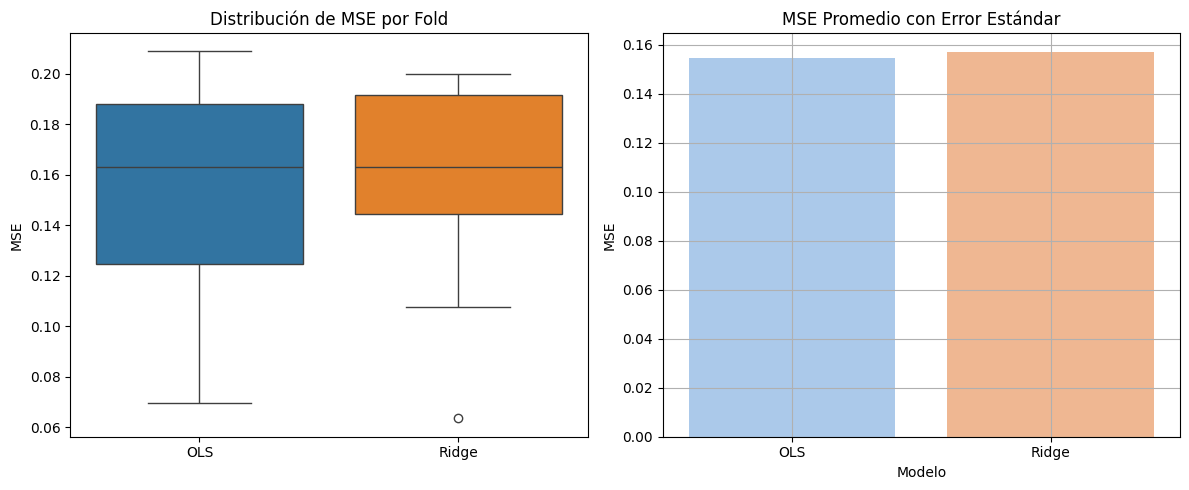


--- Test T Pareado ---
Estadístico t: -0.2119
Valor p: 0.8369


In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import ttest_rel

# Paso 1: Todos los datos
x_full = X_predictors
y_full = y_target.values

# Paso 2: Realizar 10-fold CV para OLS y Ridge
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Crear pipelines para asegurar estandarización dentro de cada fold
ols_pipe = make_pipeline(StandardScaler(), LinearRegression())
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=optimal_lambda))

# OLS
ols_mse_scores = -cross_val_score(ols_pipe, x_full, y_full, cv = cv, scoring = 'neg_mean_squared_error')

# Ridge con λ*
ridge_scores = -cross_val_score(ridge_pipe, x_full, y_full, cv = cv, scoring = 'neg_mean_squared_error')

# Paso 3: Modelos
ols_mean = np.mean(ols_mse_scores)
ridge_mean = np.mean(ridge_scores)
ols_se = np.std(ols_mse_scores, ddof=1) / np.sqrt(cv.get_n_splits())
ridge_se = np.std(ridge_scores, ddof=1) / np.sqrt(cv.get_n_splits())

print(f"\n--- Resultados de Validación Cruzada {cv.get_n_splits()}-fold ---")
print(f"OLS - MSE Promedio: {ols_mean:.4f}, Error Estándar: {ols_se:.4f}")
print(f"Ridge - MSE Promedio: {ridge_mean:.4f}, Error Estándar: {ridge_se:.4f}")

# Paso 4: Visualizar
plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=pd.DataFrame({'OLS': ols_mse_scores, 'Ridge': ridge_scores}))
plt.ylabel('MSE')
plt.title('Distribución de MSE por Fold')

# Barplot con error estándar
plt.subplot(1, 2, 2)
mse_df = pd.DataFrame({
    'Modelo': ['OLS', 'Ridge'],
    'MSE Promedio': [ols_mean, ridge_mean],
    'Error Estándar': [ols_se, ridge_se]
})
sns.barplot(data=mse_df, x='Modelo', y='MSE Promedio', palette='pastel', capsize=0.2)
plt.title('MSE Promedio con Error Estándar')
plt.ylabel('MSE')
plt.grid(True)

plt.tight_layout()
plt.show()

# Paso 5: Test pareado
t_stat, p_value = ttest_rel(ols_mse_scores, ridge_scores)
diferencia = ols_mean - ridge_mean

print(f"\n--- Test T Pareado ---")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

## 7.2 (3 pts) Interpretación de validación cruzada

**Responda:**
1. ¿Ridge tiene menor MSE promedio que OLS? ¿Por cuánto?

No, tiene MSE promedio ligeramente mas alto que OLS. Se diferencian por 0.0023


2. ¿Qué método muestra mayor variabilidad entre folds? ¿Qué implica sobre su robustez?

Ambos métodos muestran una variabilidad casi igual. Técnicamente, Ridge tiene un error estándar (SE) marginalmente más alto (0.0138 vs 0.0135). Esto implica que ambos modelos tienen una robustez muy similar. Su rendimiento predictivo es igualmente estable (o inestable) cuando se entrena en diferentes subconjuntos de los datos.


3. ¿El test pareado indica que la diferencia es estadísticamente significativa? Interprete el p-valor.

No, el test pareado indica que la diferencia no es estadísticamente significativa. El p-valor de 0.8369 es extremadamente alto (mucho mayor que el umbral estándar de 0.05). Esto significa que no hay evidencia para rechazar la hipótesis nula. La minúscula diferencia de MSE se debe casi con seguridad al azar y no a una superioridad real de un modelo sobre el otro.


4. ¿Por qué usar todos los datos (no split Train/Test) da una estimación más confiable del error de generalización?

Usar K-fold CV con todos los datos da una estimación más confiable que un solo split 80/20, ya que un solo split 80/20 depende mucho de la "suerte" de qué datos cayeron en el 20% de prueba. La validación cruzada promedia el error sobre 10 splits diferentes, lo que cancela el efecto del azar de una partición en particular. Y cada observación en el dataset se usa exactamente una vez como dato de validación. Esto proporciona una estimación más robusta y menos sesgada del error de generalización real del modelo.


## 8.1 (7 pts) Nested Cross-Validation para comparar múltiples algoritmos

**Contexto teórico:** Cuando comparamos métodos donde cada uno requiere ajustar hiperparámetros, usar CV simple produce **sesgo optimista**.

**Problema:** Si usamos el mismo validation set para:
1. Seleccionar hiperparámetros óptimos
2. Comparar los métodos

→ El "ganador" pudo haber tenido suerte en ese validation set

**Solución: Nested CV** (dos niveles independientes)

```
Para cada fold externo k = 1,...,K:
    ├─ Separar: Dev_k (80%) y Test_k (20%)
    │
    ├─ Loop interno sobre Dev_k:
    │   └─ CV para encontrar hiperparámetros óptimos
    │       (λ para Ridge, arquitectura para MLP, etc.)
    │
    ├─ Entrenar modelo final con hiperparámetros óptimos en todo Dev_k
    │
    └─ Evaluar HONESTAMENTE en Test_k → error e_k

Error final honesto: MSE_nested = (1/K) Σ e_k
```

**Comparar 4 algoritmos:**
- **Ridge Regression** (hiperparámetro: λ)
- **MLP (Multi-Layer Perceptron)** (hiperparámetros: hidden layers, learning rate)
- **Random Forest** (hiperparámetros: n_estimators, max_depth)
- **CatBoost** (hiperparámetros: iterations, learning_rate, depth)

**Implementar:**

1. **Loop externo:** 5-fold CV sobre todos los datos

2. Para cada fold externo $k = 1, \ldots, 5$:
   
   **A. Ridge:**
   - Loop interno: `GridSearchCV` con 5-fold CV sobre Dev_k
   - Grid: `lambdas = [0.01, 0.1, 1, 10, 100, 1000]`
   - Encontrar $\lambda^*_k$ óptimo
   - Entrenar Ridge($\lambda^*_k$) en todo Dev_k
   - Evaluar en Test_k → $MSE_{Ridge,k}$
   
   **B. MLP:**
   - Grid: `{'hidden_layer_sizes': [(50,), (100,), (50,50)], 'learning_rate_init': [0.001, 0.01]}`
   - `MLPRegressor(max_iter=500, random_state=3152)`
   - GridSearchCV con 5-fold
   - Entrenar mejor configuración en Dev_k
   - Evaluar en Test_k → $MSE_{MLP,k}$
   
   **C. Random Forest:**
   - Grid: `{'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}`
   - `RandomForestRegressor(random_state=3152)`
   - GridSearchCV con 5-fold
   - Evaluar en Test_k → $MSE_{RF,k}$
   
   **D. CatBoost:** (OPCIONAL - si tienen instalado)
   - Grid: `{'iterations': [100, 200], 'learning_rate': [0.03, 0.1], 'depth': [4, 6]}`
   - Si no tienen CatBoost, pueden usar **GradientBoostingRegressor** de sklearn
   - Evaluar en Test_k → $MSE_{CB,k}$

3. Calcular MSE promedio honesto para cada método:
   $$\overline{MSE}_{\text{Ridge}}^{nested} = \frac{1}{5}\sum_{k=1}^5 MSE_{Ridge,k}$$

4. Crear tabla comparativa:
   - Método | MSE Nested CV | SE | Ranking

5. Visualizar:
   - Boxplot de los 5 MSE de cada método
   - Comparar con CV simple del ejercicio 7.1


--- MSE Promedio de Modelos ---
Ridge:          0.1501
MLP:              0.8895
Random Forest:     0.1964
Gradient Boosting: 0.2004

--- Tabla Comparativa de MSE Promedio ---
              Modelo  MSE Promedio
0              Ridge        0.1501
1                MLP        0.8895
2      Random Forest        0.1964
3  Gradient Boosting        0.2004


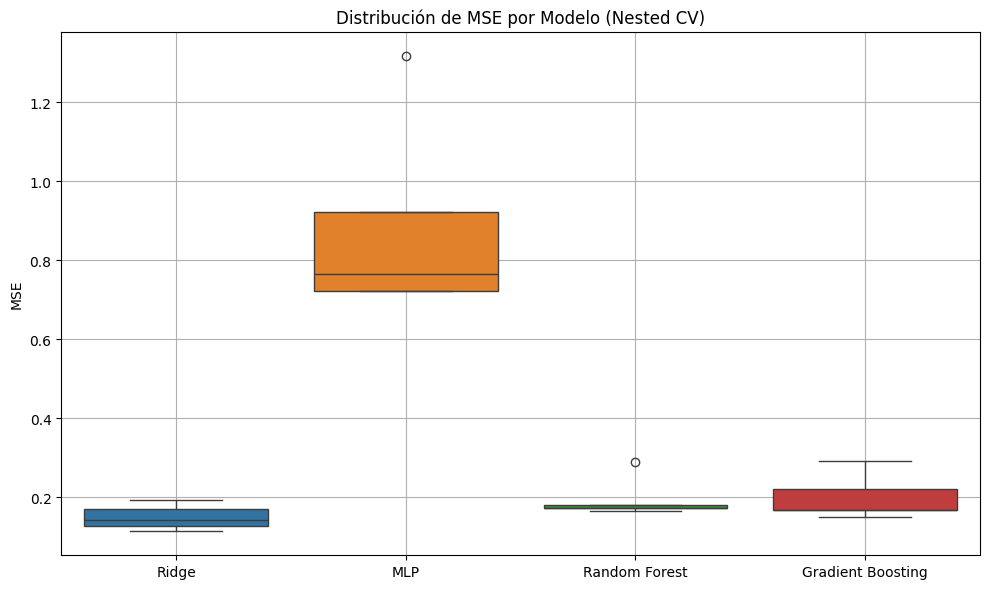

In [92]:
# Su código aquí - Nested Cross-Validation
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
# from catboost import CatBoostRegressor  # Opcional si está instalado

# ADVERTENCIA: Este código puede tomar 5-10 minutos en ejecutar
# debido al doble loop de CV

# Paso 1: Datos completos
X_full = X_predictors
y_full = y_target.values

# Paso 2: Definir folds externos(k=5)
outer_cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

# A.Rigde
ridge_grid = {'alpha': [0.1, 1, 10, 100, 1000]}

# B.MLP
mlp_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'learning_rate_init': [0.001, 0.01]
}

# C.Random Forest
rf_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None]
}

# D.CatBoost (opcional) o Gradient Boosting
gb_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.03, 0.1],
    'max_depth': [4, 6]
}

ridge_list = []
mlp_list = []
rf_list = []
gb_list = []

for train_index, test_index in outer_cv.split(X_full):
    X_train, X_test = X_full.iloc[train_index], X_full.iloc[test_index]
    y_train, y_test = y_full[train_index], y_full[test_index]
    
    # Estandarizar
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # A. Ridge
    ridge = Ridge()
    ridge_cv = GridSearchCV(ridge, ridge_grid, cv=5, scoring='neg_mean_squared_error')
    ridge_cv.fit(X_train_scaled, y_train)
    best_ridge = ridge_cv.best_estimator_
    y_pred_ridge = best_ridge.predict(X_test_scaled)
    ridge_mse = mean_squared_error(y_test, y_pred_ridge)
    ridge_list.append(ridge_mse)
    
    # B. MLP
    mlp = MLPRegressor(max_iter=1000, random_state=42)
    mlp_cv = GridSearchCV(mlp, mlp_grid, cv=5, scoring='neg_mean_squared_error')
    mlp_cv.fit(X_train_scaled, y_train)
    best_mlp = mlp_cv.best_estimator_
    y_pred_mlp = best_mlp.predict(X_test_scaled)
    mlp_mse = mean_squared_error(y_test, y_pred_mlp)
    mlp_list.append(mlp_mse)
    
    # C. Random Forest
    rf = RandomForestRegressor(random_state=42)
    rf_cv = GridSearchCV(rf, rf_grid, cv=5, scoring='neg_mean_squared_error')
    rf_cv.fit(X_train, y_train)  # RF no necesita estandarización
    best_rf = rf_cv.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    rf_mse = mean_squared_error(y_test, y_pred_rf)
    rf_list.append(rf_mse)
    
    # D. Gradient Boosting
    gb = GradientBoostingRegressor(random_state=42)
    gb_cv = GridSearchCV(gb, gb_grid, cv=5, scoring='neg_mean_squared_error')
    gb_cv.fit(X_train, y_train)  # GB no necesita estandarización
    best_gb = gb_cv.best_estimator_
    y_pred_gb = best_gb.predict(X_test)
    gb_mse = mean_squared_error(y_test, y_pred_gb)
    gb_list.append(gb_mse)
    
# Paso 3: Calcular MSE
ridge_mean_mse = np.mean(ridge_list)
mlp_mean_mse = np.mean(mlp_list)
rf_mean_mse = np.mean(rf_list)
gb_mean_mse = np.mean(gb_list)

print(f"\n--- MSE Promedio de Modelos ---")
print(f"Ridge:          {ridge_mean_mse:.4f}")
print(f"MLP:              {mlp_mean_mse:.4f}")
print(f"Random Forest:     {rf_mean_mse:.4f}")
print(f"Gradient Boosting: {gb_mean_mse:.4f}")

# Paso 4: Tabla comparativa
mse_df = pd.DataFrame({
    'Modelo': ['Ridge', 'MLP', 'Random Forest', 'Gradient Boosting'],
    'MSE Promedio': [ridge_mean_mse, mlp_mean_mse, rf_mean_mse, gb_mean_mse]
})
print("\n--- Tabla Comparativa de MSE Promedio ---")
print(mse_df.round(4))

# Paso 5: Visualizar
plt.figure(figsize=(10, 6))

# Boxplot de los MSE por modelo
mse_data = pd.DataFrame({
    'Ridge': ridge_list,
    'MLP': mlp_list,
    'Random Forest': rf_list,
    'Gradient Boosting': gb_list
})
sns.boxplot(data=mse_data)
plt.ylabel('MSE')
plt.title('Distribución de MSE por Modelo (Nested CV)')
plt.grid(True)
plt.tight_layout()
plt.show()


## 8.2 (4 pts) Interpretación de Nested CV

**Responda:**
1. ¿Qué algoritmo tiene el menor MSE en Nested CV? ¿Es Ridge el ganador o algún método de ML?
2. Compare MSE de Ridge en CV simple (ejercicio 7.1) vs Nested CV. ¿Hay diferencia? ¿Cuánto **sesgo optimista** había?
3. ¿Los hiperparámetros óptimos encontrados en cada fold externo son consistentes o varían mucho?
4. Después de este análisis riguroso, ¿qué método recomendarías para producción y por qué?

## 9.1 (4 pts) Análisis de estabilidad predictiva con Bootstrap

**Contexto:** Queremos evaluar qué tan estables son las predicciones de cada modelo cuando hay variabilidad en los datos de entrenamiento.

**Método:** Para un conjunto de observaciones de test fijas, realizar bootstrap sobre train y ver cuánto varían las predicciones.

**Implementar:**
1. Crear split Train (80%) / Test (20%) fijo

2. Seleccionar 10 observaciones representativas de Test (variedad de valores de y)

3. Para Ridge, MLP y Random Forest:
   - Realizar B = 100 réplicas bootstrap:
     - Remuestrear Train con reemplazo
     - Ajustar modelo en muestra bootstrap (con hiperparámetros del ejercicio 8.1)
     - Predecir en las 10 observaciones de Test
   - Para cada observación de test:
     - Calcular desviación estándar de las 100 predicciones
     - Calcular rango (max - min)

4. Comparar:
   - Promedio de desviaciones estándar por método
   - Promedio de rangos por método
   - Visualizar: boxplot de desviaciones estándar de predicciones para cada método

5. Para una observación específica, graficar:
   - Histograma de las 100 predicciones de cada método

In [88]:
# Su código aquí - Estabilidad predictiva


## 9.2 (3 pts) Interpretación de estabilidad predictiva

**Responda:**
1. ¿Qué método produce predicciones más estables (menor desviación estándar promedio)?
2. ¿Hay diferencia entre la estabilidad de predicciones para observaciones con y bajo vs y alto?
3. ¿Por qué es importante la estabilidad predictiva además de la precisión (MSE bajo)?
4. ¿Cómo se relaciona esta estabilidad predictiva con la estabilidad de coeficientes analizada en el ejercicio 3.1?

## 10 (4 pts) Conclusiones finales

**Sintetice sus hallazgos respondiendo:**

1. **Sobre multicolinealidad y Ridge:**
   - ¿Cómo el diagnóstico de multicolinealidad justificó el uso de Ridge?
   - ¿En qué porcentaje mejoró la estabilidad Ridge vs OLS?
   - ¿Hubo trade-off significativo en términos de MSE?

2. **Sobre métodos de remuestreo:**
   - ¿Qué valor agregaron Bootstrap y Jackknife al análisis?
   - ¿Cuándo fue crucial usar BCa en lugar de percentil simple?
   - ¿Cuál método (Bootstrap/Jackknife) prefiere para este tipo de problemas?

3. **Sobre validación y comparación de modelos:**
   - ¿Por qué Nested CV es crucial para comparaciones honestas?
   - ¿Cuánto sesgo optimista detectó en CV simple?
   - ¿Qué modelo final recomendaría para producción?

4. **Recomendación final:**
   - Si tuviera que implementar UN modelo en producción para predecir promedio_final, ¿cuál elegiría considerando:
     * Precisión (MSE)
     * Estabilidad
     * Interpretabilidad
     * Costo computacional
   - Justifique su decisión con evidencia cuantitativa de la tarea.